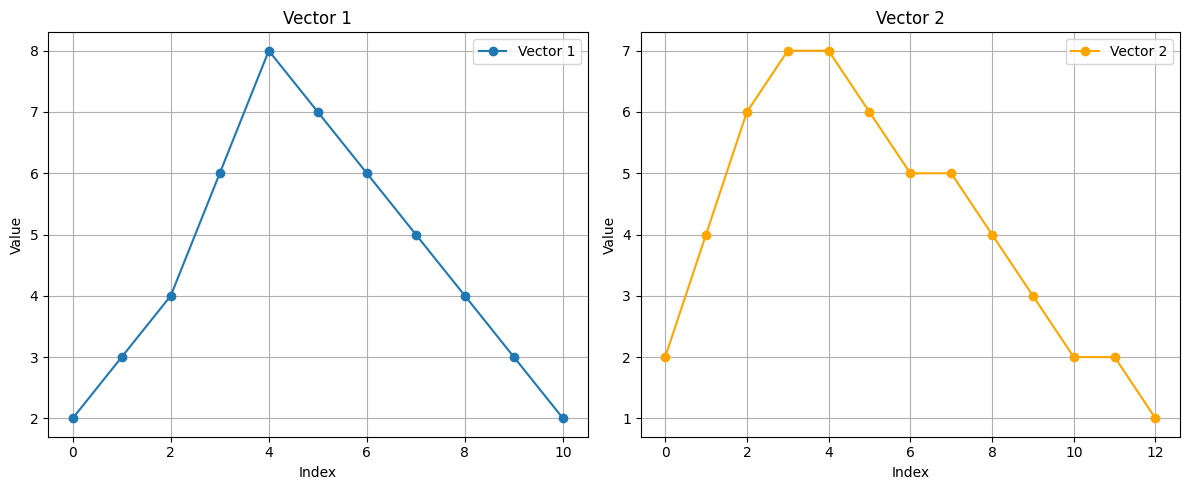

Observation:
Vector 2 is longer than Vector 1 and appears to be a stretched and slightly shifted version of it.

Although both follow similar up-down trends, Vector 2 contains repeated or extended values,
indicating slower or varied temporal evolution of the same general shape.



In [ ]:
# ---------------------------------------------------------------
# (a) Plot both vectors to visualize their patterns
# ---------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Given Data
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

# Plot both vectors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(vector1, marker='o', label='Vector 1')
plt.title('Vector 1')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vector2, marker='o', color='orange', label='Vector 2')
plt.title('Vector 2')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Observation:")
print("Vector 2 is longer than Vector 1 and appears to be a stretched and slightly shifted version of it.\n")
print("Although both follow similar up-down trends, Vector 2 contains repeated or extended values,")
print("indicating slower or varied temporal evolution of the same general shape.\n")

In [ ]:
# ---------------------------------------------------------------
# (b) Implement the Dynamic Time Warping algorithm
# ---------------------------------------------------------------

def dtw(v1, v2):
    n = len(v1)
    m = len(v2)

    # Initialize the DTW matrix with infinity
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    # Populate the DTW matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(v1[i - 1] - v2[j - 1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i - 1, j],     # insertion
                dtw_matrix[i, j - 1],     # deletion
                dtw_matrix[i - 1, j - 1]  # match
            )
    return dtw_matrix

dtw_matrix = dtw(vector1, vector2)

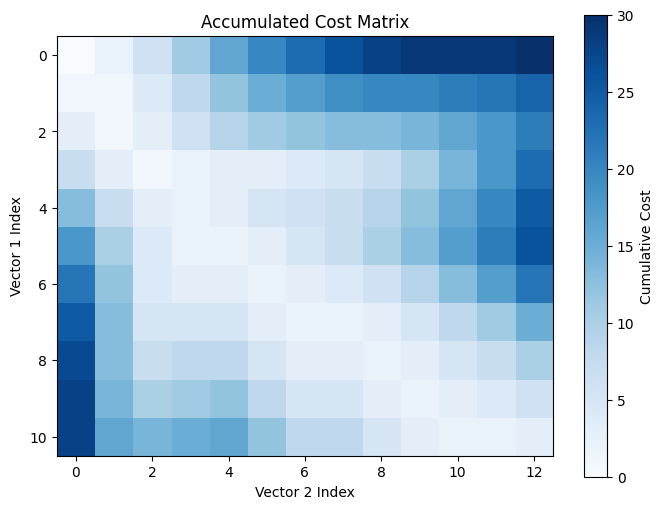

Interpretation:
The accumulated cost matrix shows how much cumulative cost is required to align each element of Vector 1
with each element of Vector 2. Lower values (darker blue) indicate smaller alignment costs,
where the two sequences have more similar values.

Regions of higher cost (lighter areas) indicate mismatched portions that require more time warping.



In [ ]:
# ---------------------------------------------------------------
# (c) Compute and visualize the accumulated cost matrix
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.imshow(dtw_matrix[1:, 1:], interpolation='nearest', cmap='Blues')
plt.title('Accumulated Cost Matrix')
plt.xlabel('Vector 2 Index')
plt.ylabel('Vector 1 Index')
plt.colorbar(label='Cumulative Cost')
plt.show()

print("Interpretation:")
print("The accumulated cost matrix shows how much cumulative cost is required to align each element of Vector 1")
print("with each element of Vector 2. Lower values (darker blue) indicate smaller alignment costs,")
print("where the two sequences have more similar values.\n")
print("Regions of higher cost (lighter areas) indicate mismatched portions that require more time warping.\n")


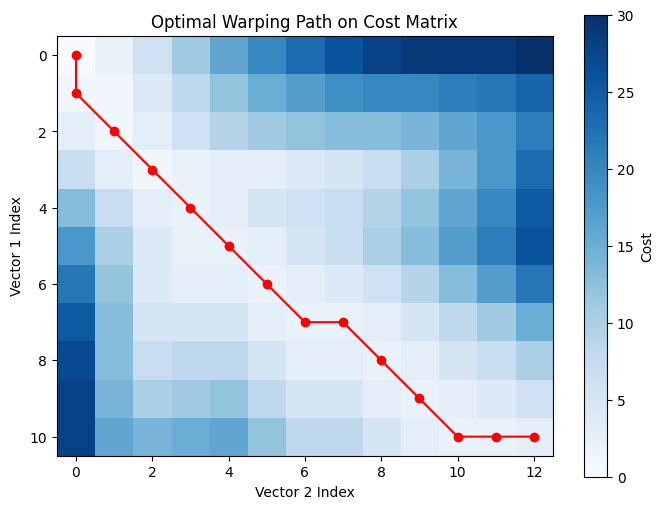

Interpretation:
The red line represents the optimal warping path that minimizes total alignment cost.
Diagonal sections indicate a near one-to-one alignment (similar pace),
while horizontal or vertical moves indicate time-stretching or compression.
This shows how DTW non-linearly maps elements of Vector 2 to match Vector 1.



In [ ]:
# ---------------------------------------------------------------
# (d) Find and visualize the optimal warping path
# ---------------------------------------------------------------

def dtw_path(dtw_matrix):
    i, j = np.array(dtw_matrix.shape) - 1
    path = [(i - 1, j - 1)]

    # Backtrack to find optimal path
    while (i > 1) or (j > 1):
        directions = [(i - 1, j - 1), (i - 1, j), (i, j - 1)]
        costs = [dtw_matrix[d] for d in directions]
        min_cost_index = np.argmin(costs)
        i, j = directions[min_cost_index]
        path.append((i - 1, j - 1))

    path.reverse()
    return path

path = dtw_path(dtw_matrix)
path_x, path_y = zip(*path)

# Visualize the warping path
plt.figure(figsize=(8, 6))
plt.imshow(dtw_matrix[1:, 1:], interpolation='nearest', cmap='Blues')
plt.plot(path_y, path_x, '-o', color='red')
plt.title('Optimal Warping Path on Cost Matrix')
plt.xlabel('Vector 2 Index')
plt.ylabel('Vector 1 Index')
plt.colorbar(label='Cost')
plt.show()

print("Interpretation:")
print("The red line represents the optimal warping path that minimizes total alignment cost.")
print("Diagonal sections indicate a near one-to-one alignment (similar pace),")
print("while horizontal or vertical moves indicate time-stretching or compression.")
print("This shows how DTW non-linearly maps elements of Vector 2 to match Vector 1.\n")


In [ ]:
# ---------------------------------------------------------------
# (e) Calculate the DTW distance
# ---------------------------------------------------------------

dtw_distance = dtw_matrix[-1, -1]
print(f"DTW Distance between Vector 1 and Vector 2: {dtw_distance:.2f}\n")

print("Interpretation:")
print("The DTW distance is the cumulative minimum cost required to align both vectors.")
print("A smaller DTW distance implies a higher degree of similarity.")
print("Since both vectors follow a similar overall pattern, the DTW distance value is relatively small,\n"
      "indicating that despite temporal distortions, their shapes are closely matched.\n")

DTW Distance between Vector 1 and Vector 2: 3.00

Interpretation:
The DTW distance is the cumulative minimum cost required to align both vectors.
A smaller DTW distance implies a higher degree of similarity.
Since both vectors follow a similar overall pattern, the DTW distance value is relatively small,
indicating that despite temporal distortions, their shapes are closely matched.



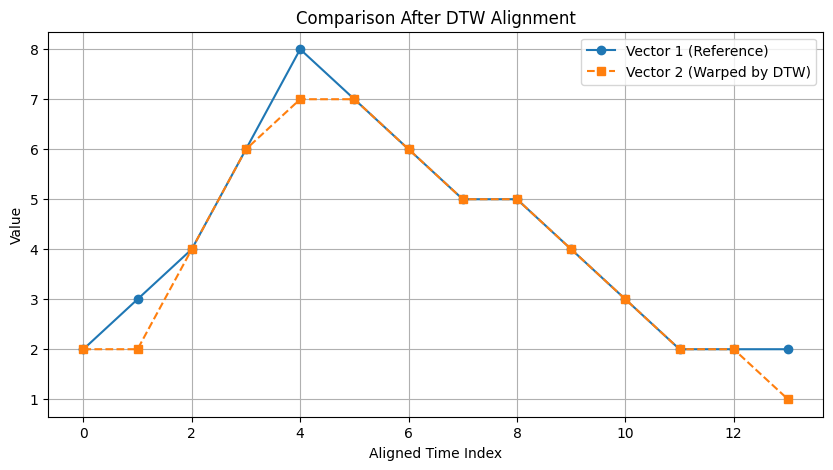

Visualization Interpretation:
After applying DTW, both vectors are resynchronized in time.
The warped version of Vector 2 (dashed line) now aligns closely with Vector 1's shape and peaks.
DTW has effectively stretched or compressed different segments so that corresponding patterns match in time.
This demonstrates DTW’s power in aligning signals that vary in timing or speaking rate (useful in speech processing).



In [ ]:
# ---------------------------------------------------------------
# (g) Visualization: Comparison of Vectors After DTW Alignment
# ---------------------------------------------------------------

# Using the warping path computed earlier to align both vectors
aligned_v1 = []
aligned_v2 = []

for (i, j) in path:
    aligned_v1.append(vector1[i])
    aligned_v2.append(vector2[j])

# Convert to numpy arrays
aligned_v1 = np.array(aligned_v1)
aligned_v2 = np.array(aligned_v2)

# Plot aligned sequences for visual comparison
plt.figure(figsize=(10, 5))
plt.plot(aligned_v1, label='Vector 1 (Reference)', marker='o')
plt.plot(aligned_v2, label='Vector 2 (Warped by DTW)', marker='s', linestyle='--')
plt.title('Comparison After DTW Alignment')
plt.xlabel('Aligned Time Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Interpretation of the visualization
print("Visualization Interpretation:")
print("After applying DTW, both vectors are resynchronized in time.")
print("The warped version of Vector 2 (dashed line) now aligns closely with Vector 1's shape and peaks.")
print("DTW has effectively stretched or compressed different segments so that corresponding patterns match in time.")
print("This demonstrates DTW’s power in aligning signals that vary in timing or speaking rate (useful in speech processing).\n")


In [ ]:
# ---------------------------------------------------------------
# (f) Inference
# ---------------------------------------------------------------

inference = """
Inference:
Dynamic Time Warping (DTW) effectively aligns two sequences that may vary in time or speed.
Unlike simple linear normalization, DTW allows non-linear mapping between indices — meaning
that one section of Vector 2 can be stretched or compressed to match corresponding parts of Vector 1.

The warping path (red line) clearly shows these local stretches and compressions, capturing
temporal variations between the two sequences. The DTW distance quantitatively measures how
much adjustment is required for perfect alignment — smaller distances indicate higher similarity.

In this experiment, the DTW distance value confirms that Vector 1 and Vector 2 share similar
patterns, even though one is slower and slightly shifted. Thus, DTW is highly useful for tasks
like speech recognition, where different speakers may pronounce the same word at varying speeds.
"""
print(inference)


Inference:
Dynamic Time Warping (DTW) effectively aligns two sequences that may vary in time or speed.
Unlike simple linear normalization, DTW allows non-linear mapping between indices — meaning
that one section of Vector 2 can be stretched or compressed to match corresponding parts of Vector 1.

The warping path (red line) clearly shows these local stretches and compressions, capturing
temporal variations between the two sequences. The DTW distance quantitatively measures how
much adjustment is required for perfect alignment — smaller distances indicate higher similarity.

In this experiment, the DTW distance value confirms that Vector 1 and Vector 2 share similar
patterns, even though one is slower and slightly shifted. Thus, DTW is highly useful for tasks
like speech recognition, where different speakers may pronounce the same word at varying speeds.

